# 03 — Modelling

Baseline univariate models and primary regularised model.

**Science check:** Confirm hypotheses are written in `.pre-analysis-plan.md` before running any cell below. Check class balance after labelling.

In [1]:
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '..')

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load Feature Matrix

In [2]:
import os

# Use absolute path so kernel working-directory doesn't matter
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if not os.path.exists(os.path.join(PROJECT_ROOT, 'data', 'processed', 'feature_matrix.parquet')):
    # Fallback: already at root
    PROJECT_ROOT = os.getcwd()

FEATURE_MATRIX_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'feature_matrix.parquet')
print('Reading:', FEATURE_MATRIX_PATH)

feature_matrix = pd.read_parquet(FEATURE_MATRIX_PATH)
print(f'Feature matrix: {feature_matrix.shape[0]:,} rows × {feature_matrix.shape[1]} columns')
feature_matrix.head()

Reading: /Users/oliviavelte/Desktop/human_influence_for_aisi/data/processed/feature_matrix.parquet


Feature matrix: 505,397 rows × 17 columns


,hashed_ip,conversation_id,session_number,n_user_turns,return_interval_hours,log_n_user_turns,log_return_interval_hours,fpp_rate,self_disclosure_rate,hedging_rate,filler_rate,gratitude_rate,refusal_resistance_rate,question_to_statement_ratio,mean_message_length,type_token_ratio,sentiment_slope
0,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...,101001,1,1,NaN,0.693147,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.090909,232.0,0.637931,0.0
1,846e43fb5fbb4b8cfbafa17083387aad62e58f5fb23482...,101007,1,1,NaN,0.693147,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,44.0,0.568182,0.0
2,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...,101008,2,1,0.065556,0.693147,0.063496,0.0,0.0,0.0,0.004167,0.0,0.0,0.090909,240.0,0.641667,0.0
3,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...,101012,3,1,0.031111,0.693147,0.030637,0.0,0.0,0.0,0.003802,0.0,0.0,0.088235,263.0,0.627376,0.0
4,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...,101017,4,1,0.039167,0.693147,0.038419,0.0,0.0,0.0,0.003497,0.0,0.0,0.083333,286.0,0.608392,0.0


## 2. Label High-Dependency Users

Users with early features:         12,577
Users with late labels (sess 10+): 12,497

Class balance:
Low-dependency     9483
High-dependency    3014
Name: count, dtype: int64
Positive rate: 24.12%


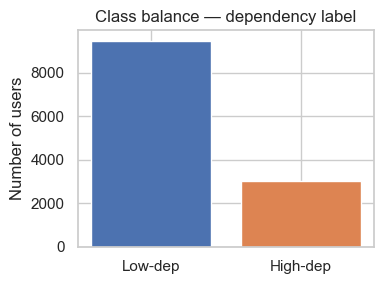

In [3]:
from src.features.pipeline import get_early_session_features, get_late_session_features
from src.modelling.evaluation import label_high_dependency

early  = get_early_session_features(feature_matrix)
late   = get_late_session_features(feature_matrix)
labels = label_high_dependency(late)

# Align: keep only users who have BOTH early features AND late-session labels
early_indexed = early.set_index('hashed_ip')
y_aligned     = labels.reindex(early_indexed.index)
valid_mask    = y_aligned.notna()
X_early       = early_indexed[valid_mask]
y             = y_aligned[valid_mask].astype(int).values

print(f'Users with early features:         {len(early_indexed):,}')
print(f'Users with late labels (sess 10+): {valid_mask.sum():,}')
vc = pd.Series(y).value_counts().sort_index().rename({0: 'Low-dependency', 1: 'High-dependency'})
print(f'\nClass balance:\n{vc}')
print(f'Positive rate: {y.mean():.2%}')

FIGURES_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(['Low-dep', 'High-dep'], vc.values, color=['#4C72B0', '#DD8452'])
ax.set_ylabel('Number of users')
ax.set_title('Class balance — dependency label')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_class_balance.png'), dpi=150)
plt.show()

## 3. Univariate Baseline Models

In [4]:
from src.modelling.baseline import run_univariate_baselines

baseline_results = run_univariate_baselines(X_early, y)
baseline_results

,feature,auc,cohens_d,p_raw,p_corrected_bh,significant_bh
0,log_n_user_turns,0.659319,0.590547,2.546538e-135,3.055846e-134,True
1,filler_rate,0.599316,0.172626,8.622765e-17,1.478188e-16,True
2,fpp_rate,0.575233,0.272029,1.071418e-23,2.571403e-23,True
3,question_to_statement_ratio,0.570671,0.215747,2.187901e-21,4.375802e-21,True
4,type_token_ratio,0.561952,-0.241232,1.485710e-28,4.457129e-28,True
5,hedging_rate,0.560794,0.193982,8.699393e-15,1.304909e-14,True
6,log_return_interval_hours,0.544930,-0.221465,1.213662e-30,4.854649e-30,True
7,refusal_resistance_rate,0.540040,0.371517,1.126982e-39,6.761890e-39,True
8,self_disclosure_rate,0.510220,0.054098,2.114174e-02,2.537009e-02,True
9,sentiment_slope,0.506759,-0.051959,5.214807e-02,5.688881e-02,False


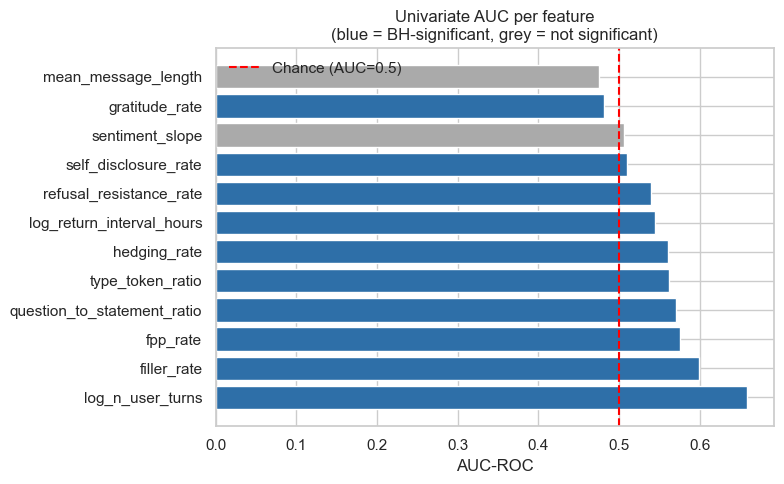

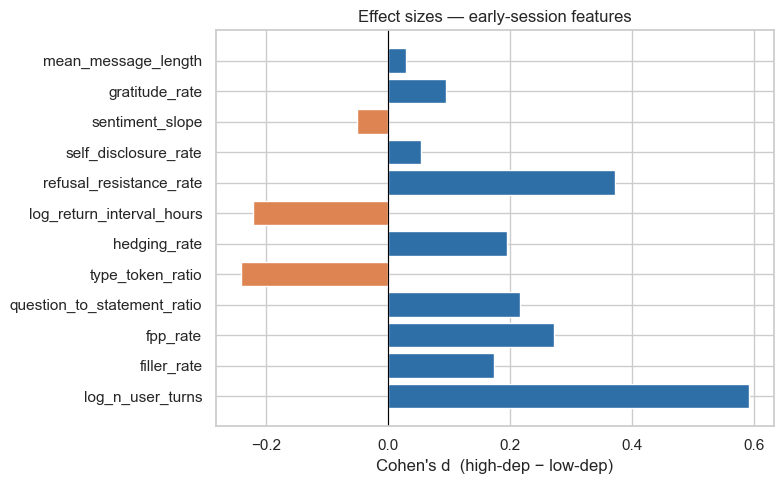

In [5]:
TABLES_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'tables')
os.makedirs(TABLES_DIR, exist_ok=True)

baseline_results.to_csv(os.path.join(TABLES_DIR, 'baseline_results.csv'), index=False)

# AUC plot
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2E6FA8' if sig else '#AAAAAA' for sig in baseline_results['significant_bh']]
ax.barh(baseline_results['feature'], baseline_results['auc'], color=colors)
ax.axvline(0.5, color='red', linestyle='--', label='Chance (AUC=0.5)')
ax.set_xlabel('AUC-ROC')
ax.set_title('Univariate AUC per feature\n(blue = BH-significant, grey = not significant)')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_univariate_auc.png'), dpi=150)
plt.show()

# Cohen's d plot
fig, ax = plt.subplots(figsize=(8, 5))
colors_d = ['#2E6FA8' if d > 0 else '#DD8452' for d in baseline_results['cohens_d']]
ax.barh(baseline_results['feature'], baseline_results['cohens_d'], color=colors_d)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Cohen's d  (high-dep − low-dep)")
ax.set_title("Effect sizes — early-session features")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_cohens_d.png'), dpi=150)
plt.show()

## 4. Main Model (L1-Regularised Logistic Regression)

In [6]:
from src.modelling.main_model import build_pipeline, add_negative_control, get_feature_importances
from src.modelling.evaluation import cross_validate_model

X_with_control = add_negative_control(X_early)
feature_names  = list(X_with_control.columns)
X_arr          = X_with_control.values
user_ids       = np.array(X_with_control.index)

pipeline   = build_pipeline(penalty='l1', C=1.0, random_state=RANDOM_SEED)
cv_results = cross_validate_model(pipeline, X_arr, y, user_ids, n_folds=10)

print('=== 10-fold cross-validation (user-level stratified) ===')
print(f"Mean AUC:               {cv_results['mean_auc']:.3f} ± {cv_results['std_auc']:.3f}")
print(f"Observed AUC (pooled):  {cv_results['observed_auc']:.3f}")
print(f"Mean balanced accuracy: {cv_results['mean_balanced_accuracy']:.3f}")
print(f"Mean precision:         {cv_results['mean_precision']:.3f}")
print(f"Mean recall:            {cv_results['mean_recall']:.3f}")
print(f"\nPer-fold AUCs: {[round(a, 3) for a in cv_results['fold_aucs']]}")

=== 10-fold cross-validation (user-level stratified) ===
Mean AUC:               0.712 ± 0.014
Observed AUC (pooled):  0.712
Mean balanced accuracy: 0.661
Mean precision:         0.402
Mean recall:            0.611

Per-fold AUCs: [0.718, 0.702, 0.696, 0.688, 0.727, 0.719, 0.714, 0.723, 0.7, 0.737]


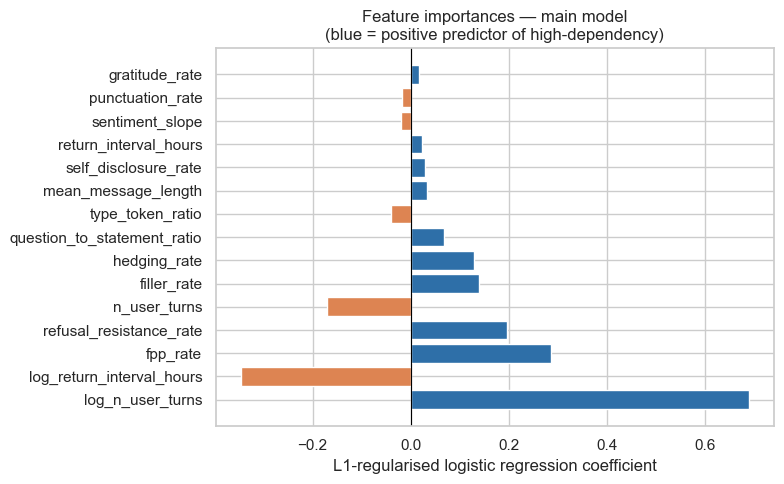

,feature,coefficient,abs_coef
0,log_n_user_turns,0.688103,0.688103
1,log_return_interval_hours,-0.345783,0.345783
2,fpp_rate,0.286465,0.286465
3,refusal_resistance_rate,0.195655,0.195655
4,n_user_turns,-0.170643,0.170643
5,filler_rate,0.139832,0.139832
6,hedging_rate,0.129071,0.129071
7,question_to_statement_ratio,0.067741,0.067741
8,type_token_ratio,-0.040855,0.040855
9,mean_message_length,0.033276,0.033276


In [7]:
pipeline.fit(X_arr, y)
importances = get_feature_importances(pipeline, feature_names)
importances.to_csv(os.path.join(TABLES_DIR, 'feature_importances.csv'), index=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors_imp = ['#2E6FA8' if c > 0 else '#DD8452' for c in importances['coefficient']]
ax.barh(importances['feature'], importances['coefficient'], color=colors_imp)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('L1-regularised logistic regression coefficient')
ax.set_title('Feature importances — main model\n(blue = positive predictor of high-dependency)')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_feature_importances.png'), dpi=150)
plt.show()

importances